In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from scipy.optimize import minimize
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA


In [4]:
df = pd.read_csv('diabetes.csv')


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [9]:
df.isnull().values.any()


False

In [10]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
df["Outcome"].unique()

array([1, 0], dtype=int64)

In [12]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
correlation_matrix = df.corr()
print(correlation_matrix)


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

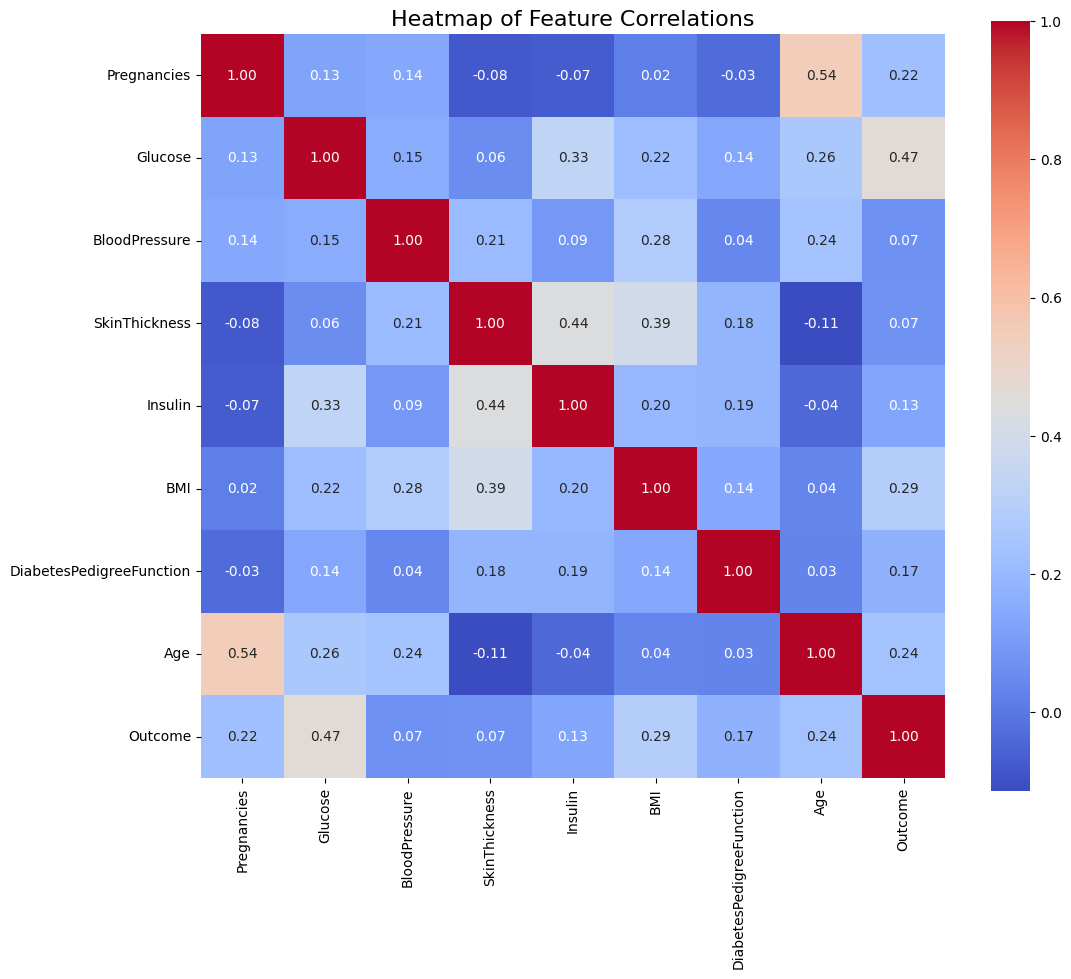

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap of Feature Correlations", fontsize=16)
plt.show()

In [15]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

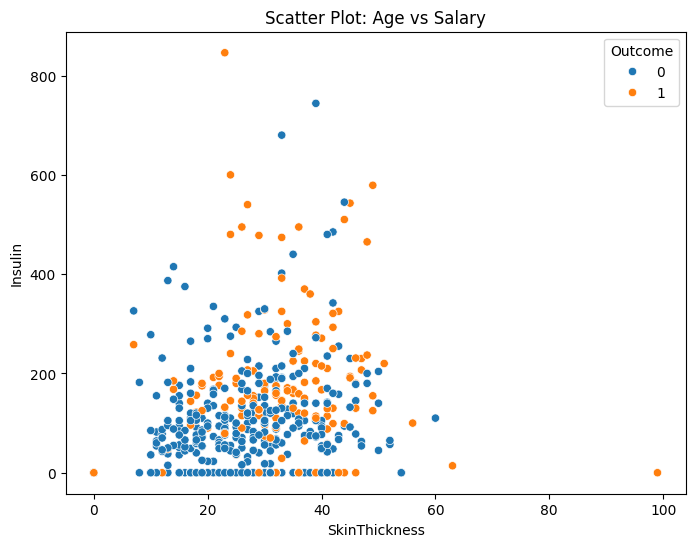

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='SkinThickness', y='Insulin', hue='Outcome')
plt.title('Scatter Plot: Age vs Salary')
plt.show()

In [17]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

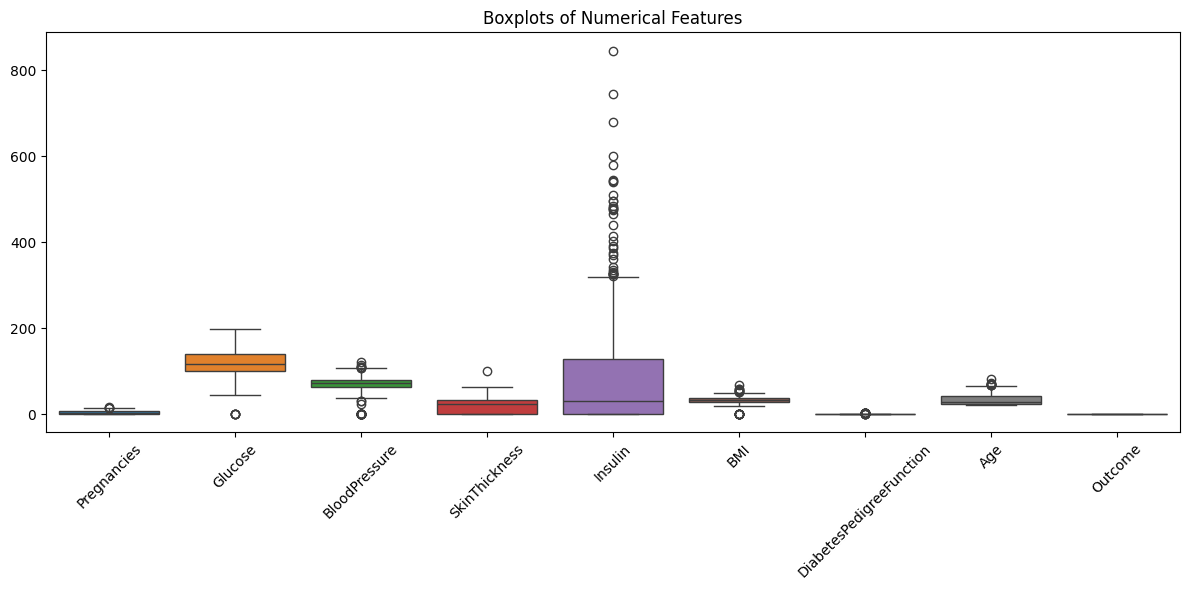

In [18]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [19]:
df = pd.read_csv('diabetes.csv')


In [20]:
Zlist = {"SkinThickness","Glucose","BloodPressure","Insulin","BMI"}

In [21]:
for i in  Zlist:
    sum = 0
    (0 in df[i].values)
    sum = ((df[i] == 0).sum())
    print(f"{i} have {sum} zeros")


Insulin have 374 zeros
BMI have 11 zeros
Glucose have 5 zeros
SkinThickness have 227 zeros
BloodPressure have 35 zeros


In [22]:
for i in Zlist:
    median_value = df[i][df[i] != 0].median()
    df[i] = df[i].replace(0,median_value)

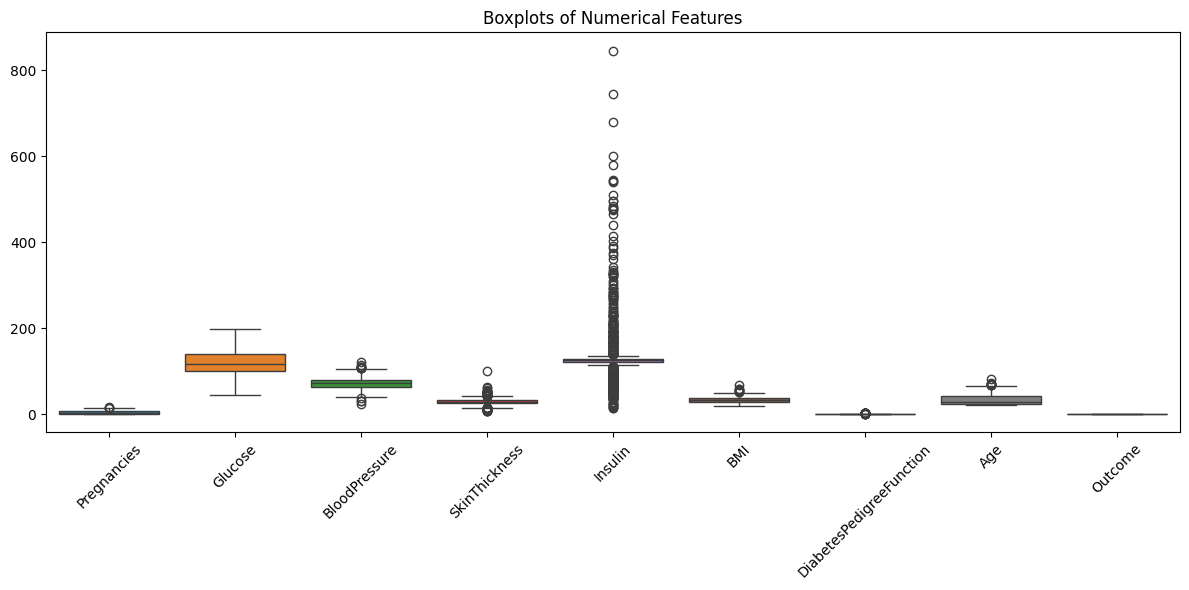

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [24]:
outList = {"SkinThickness","Insulin","Age","DiabetesPedigreeFunction","Pregnancies","BMI","BloodPressure"}

In [25]:
for i in outList:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df[i] = df[i].apply(
        lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
)

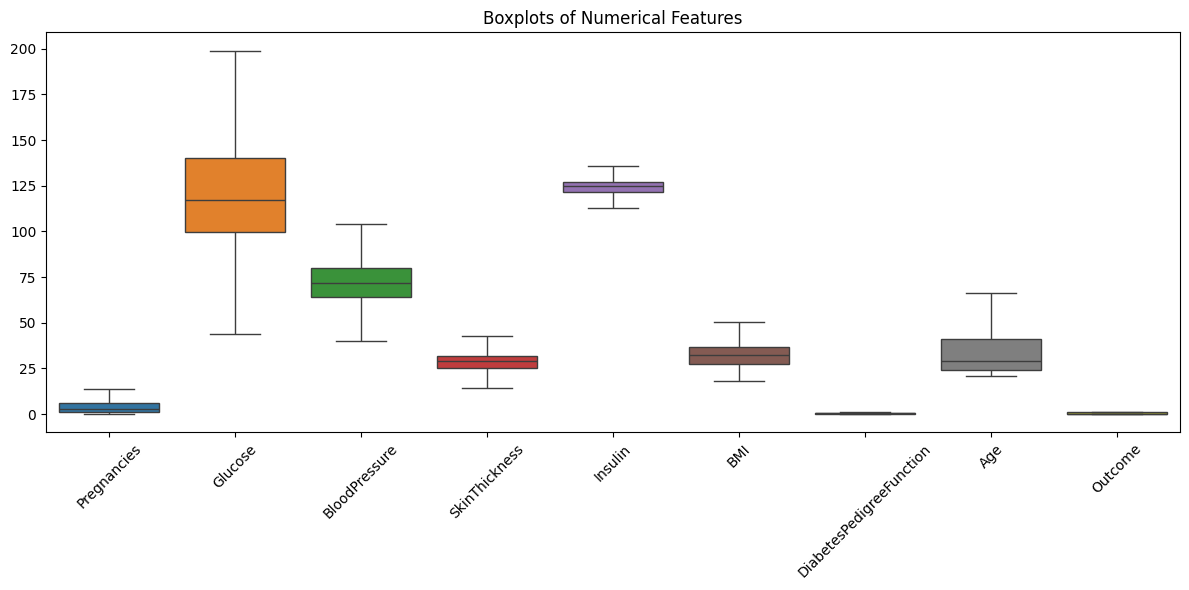

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features')
plt.tight_layout()
plt.show()

In [27]:
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [28]:
df['Outcome'].value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

In [54]:
X = df.drop("Outcome",axis=1)
y = df["Outcome"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [31]:
weights = np.ones(X.shape[1])
X_weighted = X * weights
dist_matrix = cdist(X_weighted, X_weighted, metric='euclidean') 

In [32]:
dist_matrix

array([[ 0.        , 66.90348403, 41.94153103, ..., 38.41772441,
        26.65196586, 61.71982942],
       [66.90348403,  0.        , 98.33103803, ..., 39.14315855,
        44.5561444 , 12.74524602],
       [41.94153103, 98.33103803,  0.        , ..., 64.12961838,
        59.87774486, 91.21698005],
       ...,
       [38.41772441, 39.14315855, 64.12961838, ...,  0.        ,
        25.92752285, 32.88860783],
       [26.65196586, 44.5561444 , 59.87774486, ..., 25.92752285,
         0.        , 42.06056533],
       [61.71982942, 12.74524602, 91.21698005, ..., 32.88860783,
        42.06056533,  0.        ]])

In [33]:
 X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [34]:

weights = np.ones(len(X.columns))
weights[list(X.columns).index('BMI')] = 1.2
weights[list(X.columns).index('Glucose')] = 1.47
X_weighted = X * weights
dist_matrix = cdist(X_weighted, X_weighted, metric='euclidean')



In [59]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148,72.0,35.0,125.000,33.6,0.627,50.0
1,1.0,85,66.0,29.0,125.000,26.6,0.351,31.0
2,8.0,183,64.0,29.0,125.000,23.3,0.672,32.0
3,1.0,89,66.0,23.0,112.875,28.1,0.167,21.0
4,0.0,137,40.0,35.0,135.875,43.1,1.200,33.0
...,...,...,...,...,...,...,...,...
763,10.0,101,76.0,42.5,135.875,32.9,0.171,63.0
764,2.0,122,70.0,27.0,125.000,36.8,0.340,27.0
765,5.0,121,72.0,23.0,112.875,26.2,0.245,30.0
766,1.0,126,60.0,29.0,125.000,30.1,0.349,47.0


In [58]:
X_weighted.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,217.56,72.0,35.0,125.000,40.32,0.627,50.0
1,1.0,124.95,66.0,29.0,125.000,31.92,0.351,31.0
2,8.0,269.01,64.0,29.0,125.000,27.96,0.672,32.0
3,1.0,130.83,66.0,23.0,112.875,33.72,0.167,21.0
4,0.0,201.39,40.0,35.0,135.875,51.72,1.200,33.0


In [36]:
dist_matrix

array([[  0.        ,  95.42142462,  56.81438308, ...,  48.43874533,
         35.74343134,  85.58951714],
       [ 95.42142462,   0.        , 144.30200359, ...,  55.10702007,
         62.78624773,  15.5914238 ],
       [ 56.81438308, 144.30200359,   0.        , ...,  92.62185462,
         85.89210691, 133.21414283],
       ...,
       [ 48.43874533,  55.10702007,  92.62185462, ...,   0.        ,
         26.60735502,  44.71652631],
       [ 35.74343134,  62.78624773,  85.89210691, ...,  26.60735502,
          0.        ,  55.07586455],
       [ 85.58951714,  15.5914238 , 133.21414283, ...,  44.71652631,
         55.07586455,   0.        ]])

In [ ]:
# X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
#        'BMI', 'DiabetesPedigreeFunction', 'Age']]
# y = df.iloc[:,-1]

In [60]:
X = X_weighted
y = df.iloc[:,-1]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

In [62]:
X_train.shape

(691, 8)

In [63]:

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(sampling_strategy=0.8)),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    cv_scores.append(np.mean(scores))

best_k = k_range[np.argmax(cv_scores)]
print(f"✅ Best k from cross-validation: {best_k}")

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Final Accuracy on Test: {acc:.4f}\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🧱 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


✅ Best k from cross-validation: 14

🎯 Final Accuracy on Test: 0.7792

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82        50
           1       0.66      0.78      0.71        27

    accuracy                           0.78        77
   macro avg       0.76      0.78      0.77        77
weighted avg       0.79      0.78      0.78        77

🧱 Confusion Matrix:
[[39 11]
 [ 6 21]]


In [41]:


# X_scaled = StandardScaler().fit_transform(X_train)
# X_pca = PCA(n_components=2).fit_transform(X_scaled)

# plt.figure(figsize=(8,6))
# plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='coolwarm', alpha=0.6)
# plt.title('PCA Projection of Training Data')
# plt.show()


In [42]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [43]:
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

In [44]:
df.iloc[0,:]

Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                     125.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64

In [64]:
knn = KNeighborsClassifier(n_neighbors=best_k,metric="euclidean")
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=14)

In [65]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7272727272727273

In [49]:
def apply_feature_weights(X, weights):
    return X * weights

def evaluate_knn(weights):
    X_train_weighted = apply_feature_weights(X_train, weights)
    X_test_weighted = apply_feature_weights(X_test, weights)
    
    model = KNeighborsClassifier(n_neighbors=best_k,metric="euclidean")
    model.fit(X_train_weighted, y_train)
    y_pred = model.predict(X_test_weighted)
    
    return 1 - accuracy_score(y_test, y_pred)  


In [50]:
initial_weights = np.zeros(X.shape[1]) 

result = minimize(evaluate_knn, initial_weights, method='Powell')
optimal_weights = result.x

print("Optimal weights:", optimal_weights)

Optimal weights: [ 2.01325221  0.31840462  1.18026658  0.85565475 -0.08170136  7.59286684
 -0.58220713 -0.06123293]


In [51]:
X_train_weighted = apply_feature_weights(X_train, optimal_weights)
X_test_weighted = apply_feature_weights(X_test, optimal_weights)

final_model = KNeighborsClassifier(n_neighbors=best_k,metric="euclidean")
final_model.fit(X_train_weighted, y_train)
final_predictions = final_model.predict(X_test_weighted)

final_accuracy = accuracy_score(y_test, final_predictions)
print("Final Accuracy with optimized weights:", final_accuracy)

Final Accuracy with optimized weights: 0.8441558441558441


In [ ]:

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.75      0.88      0.81        50
           1       0.67      0.44      0.53        27

    accuracy                           0.73        77
   macro avg       0.71      0.66      0.67        77
weighted avg       0.72      0.73      0.71        77

